In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect("../data/warehouse_new.duckdb")

In [2]:
con.execute("SHOW TABLES").fetchdf()

,name
0,customer_list_xls
1,customer_list_xlsx
2,electricity_sales_all
3,sales_2012_2017
4,sales_2018_2019


In [3]:
df_2012_2017 = con.execute("""SELECT * FROM sales_2012_2017""").fetchdf()

df_2018_2019 = con.execute("""SELECT * FROM sales_2018_2019""").fetchdf()

customer_xls = con.execute("""SELECT * FROM customer_list_xls""").fetchdf()

customer_xlsx = con.execute("""SELECT * FROM customer_list_xlsx""").fetchdf()

In [4]:
df_2012_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2396617 entries, 0 to 2396616
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   meterid                object        
 1   od_date                datetime64[ns]
 2   ordersid               object        
 3   ocd_energy             float64       
 4   ocd_taxes              float64       
 5   ocd_paymoney           float64       
 6   payforarrears          float64       
 7   ocd_servicecharge      float64       
 8   ocd_leviescharge       float64       
 9   ocd_cash_received      float64       
 10  ocd_subsidy            float64       
 11  ocd_nel_charge         float64       
 12  ocd_slv_charge         float64       
 13  ocd_vat1_charge        float64       
 14  ocd_vat2_charge        float64       
 15  ocd_month_consumption  float64       
 16  ocd_energy_cost        float64       
 17  source_sheet           object        
dtypes: datetime64[ns](1), 

In [5]:
df_2012_2017.head()

,meterid,od_date,ordersid,ocd_energy,ocd_taxes,ocd_paymoney,payforarrears,ocd_servicecharge,ocd_leviescharge,ocd_cash_received,ocd_subsidy,ocd_nel_charge,ocd_slv_charge,ocd_vat1_charge,ocd_vat2_charge,ocd_month_consumption,ocd_energy_cost,source_sheet
0,1010451111,2013-08-27 09:56:04,413082700130806,30.40,0.0,20.0,0.0,14.8788,0.0111,20.0,1.3340,0.0086,0.0025,0.0,0.0,0.0,5.1101,2012-13
1,1010451111,2013-08-27 12:13:34,413082700130996,61.65,0.0,10.0,0.0,0.0000,0.0136,10.0,3.3059,0.0105,0.0031,0.0,0.0,30.4,9.9864,2012-13
2,10010284581,2012-10-25 18:23:42,412102500004294,30.14,0.0,6.0,0.0,1.6532,0.0110,6.0,0.9920,0.0085,0.0025,0.0,0.0,0.0,4.3358,2012-13
3,10102444391,2013-12-12 14:04:52,413121200213008,32.08,0.0,15.0,0.0,2.5675,0.0115,15.0,3.9578,0.0089,0.0026,0.0,0.0,0.0,12.4210,2012-13
4,11010003761,2013-02-15 11:28:55,413021500035162,64.54,0.0,12.0,0.0,3.3064,0.0142,12.0,2.6654,0.0110,0.0032,0.0,0.0,0.0,8.6794,2012-13


In [6]:
df_2012_2017 = df_2012_2017[['meterid','od_date', 'ordersid','ocd_cash_received', 'ocd_energy']]
df_2018_2019 = df_2018_2019[['meterid','od_date','ordersid','ocd_cash_received', 'ocd_energy']]

In [7]:
customer_xls.head()

,volta river authority northern electricity department,unnamed: 1,unnamed: 2,unnamed: 3,unnamed: 4,unnamed: 5,unnamed: 6,unnamed: 7,unnamed: 8,unnamed: 9,unnamed: 10,unnamed: 11,unnamed: 12,unnamed: 13,unnamed: 14,unnamed: 15,source_sheet
0,Customer No.,Meter No.,Customer Name,Customer Address,Paid Mode.,Utility,Account Status,Account Open Date,Tariff Type,CBMS Customer No.,PPM Customer No.,Contact Person,Contact Number,Identification Number,Power Supply State,Block State,Techiman
1,501002891101,18057591261,MEG OSADOLOR,STORE@PLOT NO. 86 BLK L SECT 6S BAMIRI,Prepaid,Techiman,Active,20/01/2022,Non Residential,SQ1206960,None,MEG OSADOLOR,0560862224,None,Connected,0,Techiman
2,501002869623,017015603711,SEIBA ABINDAU,PLOT NO. 8 TUOBODOM,Prepaid,Techiman,Active,07/10/2021,Residential,SQ1203958,None,SEIDU ABINDAU,0552794548,None,Connected,0,Techiman
3,501002873318,017015801331,OPOKU BOAMAH CLEMENT,BOREHOLE@PLOT NO. 12A BLK A SECT BAMIRI,Prepaid,Techiman,Active,22/10/2021,Non Residential,SQ1205049,None,OPOKU BOAMAH CLEMENT,0596384100,None,Connected,0,Techiman
4,501002856027,20193368717,SOMUAH JOSEPH,"PLOT NO. 192 BLK B, SECT 11, ASIKO TOWN, JAMA",Prepaid,Techiman,Active,12/08/2021,Residential,SQ1202508,None,SOMUAH JOSEPH,0245726636,None,Connected,0,Techiman


In [8]:
customer_xls.columns = customer_xls.iloc[0] 
customer_xls = customer_xls[1:] 

customer_xls.head()

,Customer No.,Meter No.,Customer Name,Customer Address,Paid Mode.,Utility,Account Status,Account Open Date,Tariff Type,CBMS Customer No.,PPM Customer No.,Contact Person,Contact Number,Identification Number,Power Supply State,Block State,Techiman
1,501002891101,18057591261,MEG OSADOLOR,STORE@PLOT NO. 86 BLK L SECT 6S BAMIRI,Prepaid,Techiman,Active,20/01/2022,Non Residential,SQ1206960,None,MEG OSADOLOR,0560862224,None,Connected,0,Techiman
2,501002869623,017015603711,SEIBA ABINDAU,PLOT NO. 8 TUOBODOM,Prepaid,Techiman,Active,07/10/2021,Residential,SQ1203958,None,SEIDU ABINDAU,0552794548,None,Connected,0,Techiman
3,501002873318,017015801331,OPOKU BOAMAH CLEMENT,BOREHOLE@PLOT NO. 12A BLK A SECT BAMIRI,Prepaid,Techiman,Active,22/10/2021,Non Residential,SQ1205049,None,OPOKU BOAMAH CLEMENT,0596384100,None,Connected,0,Techiman
4,501002856027,20193368717,SOMUAH JOSEPH,"PLOT NO. 192 BLK B, SECT 11, ASIKO TOWN, JAMA",Prepaid,Techiman,Active,12/08/2021,Residential,SQ1202508,None,SOMUAH JOSEPH,0245726636,None,Connected,0,Techiman
5,501002865664,20195170715,SERWAA JAMILA,"PLOT NO. 152 BLK. A SECT. 6, TAKYIKROM",Prepaid,Techiman,Active,15/09/2021,Residential,None,None,SERWAA JAMILA,0548406768,None,Connected,0,Techiman


In [9]:
df_all = pd.concat([df_2012_2017, df_2018_2019], ignore_index=True)
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5666016 entries, 0 to 5666015
Data columns (total 5 columns):
 #   Column             Dtype         
---  ------             -----         
 0   meterid            object        
 1   od_date            datetime64[ns]
 2   ordersid           object        
 3   ocd_cash_received  float64       
 4   ocd_energy         float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 216.1+ MB


In [10]:
df_all.isnull().sum()

meterid              0
od_date              0
ordersid             0
ocd_cash_received    0
ocd_energy           0
dtype: int64

In [13]:
import pandas as pd


# --- 1. Clean + pad meter IDs to 14 digits ---
df_all['meterid'] = df_all['meterid'].astype(str).str.strip().str.zfill(14)
customer_xls['Meter No.'] = customer_xls['Meter No.'].astype(str).str.strip().str.zfill(14)

# --- 2. Merge ---
merged = df_all.merge(
    customer_xls[['Meter No.']],
    how='left',
    left_on='meterid',
    right_on='Meter No.'
)

# --- 3. Count matches ---
matches = merged['Meter No.'].notna().sum()
unmatched = merged['Meter No.'].isna().sum()

total = len(merged)
percent_unmatched = round((unmatched / total) * 100, 4)

print("Matched meterids     :", matches)
print("Unmatched meterids   :", unmatched)
print("Total rows           :", total)
print("Percent unmatched    :", f"{percent_unmatched}%")


Matched meterids     : 5255324
Unmatched meterids   : 410863
Total rows           : 5666187
Percent unmatched    : 7.2511%


KeyError: '[23.49, 45.24, 18.49, 52.87, 131.2, 94.08, 346.4, 191.25, 56.96, 156.02, 170.3, 118.04, 74.23, 261.83, 276.47, 248.06, 302.62, 61.23, 45.22, 1.3, 151.02, 112.24, 607.74, 87.26, 196.25, 298.24, 121.64, 46.97, 248.07, 75.06, 45.36, 20.34, 61.96, 158.87, 162.84, 45.7, 126.64, 120.16, 171.92, 57.87, 136.2, 34.38, 134.29, 145.8, 68.77, 35.68, 218.95, 22.73, 46.12, 4.74, 629.33, 86.66, 176.91, 149.19, 37.12, 155.16, 67.88, 101.5, 39.12, 69.23, 25.37, 307.62, 69.94, 219.66, 38.79, 47.87, 187.07, 137.53, 50.6, 321.02, 138.62, 135.46, 326.02, 243.88, 81.66, 151.48, 28.19, 104.45, 17.19, 62.4, 236.7, 64.63, 99.08, 131.37, 27.66, 89.63, 171.42, 492.59, 20.91, 33.01, 18.41, 32.27, 11.9, 43.79, 51.58, 50.14, 98.34, 918.07, 103.15, 35.75, 56.81, 54.55, 49.54, 123.77, 20.63, 114.1, 71.81, 28.33, 140.92, 200.7, 100.08, 87.58, 86.55, 112.51, 80.78, 12.82, 27.51, 44.54, 59.39, 129.96, 32.82, 22.27, 126.31, 35.8, 28.41, 51.96, 281.47, 337.34, 65.69, 34.09, 70.06, 173.47, 179.89, 143.28, 55.66,

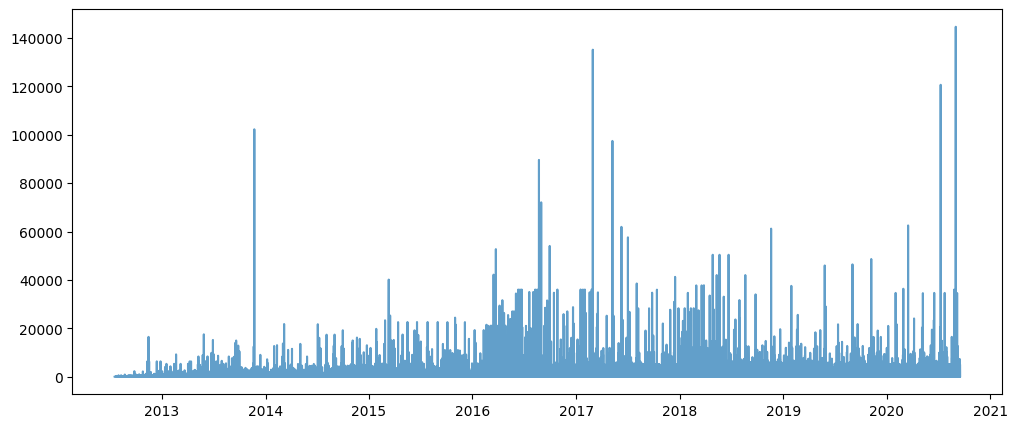

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

LOW_Q = 0.01
HIGH_Q = 0.99

df_all['od_date'] = pd.to_datetime(df_all['od_date'])

df_daily = df_all.groupby('od_date')['ocd_energy'].sum().reset_index()

low_q = df_daily['ocd_energy'].quantile(LOW_Q)
high_q = df_daily['ocd_energy'].quantile(HIGH_Q)

df_daily['is_anomaly'] = (df_daily['ocd_energy'] < low_q) | (df_daily['ocd_energy'] > high_q)

plt.figure(figsize=(12,5))
plt.plot(df_daily['od_date'], df_daily['ocd_energy'], label='Daily Total', alpha=0.7)
plt.scatter(df_daily.loc[df_daily['ocd_energy'], 'od_date'],
            df_daily.loc[df_daily['ocd_energy'], 'ocd_energy'],
            color='red', label='Anomalies')
plt.title("Daily Total ocd_energy with Anomalies")
plt.xlabel("Date")
plt.ylabel("Total ocd_energy")
plt.legend()
plt.show()


In [ ]:
matches = df_all["ordersid"].isin(customer_xls["Meter No."])
print(matches.sum(), "out of", len(df_all), "rows matched")

0 out of 5666016 rows matched
